# Multimodal posterior MAPE comparison

This notebook tests the proposed multimodal posterior strategy against the current single-ML MAPE. The current metric uses the posterior sample with the largest log likelihood. The multimodal metric clusters posterior samples with k-means, tries `k=1..5`, selects the best silhouette score, takes the ML sample inside each cluster, then uses the mode closest to the known solution for MAPE.

The multimodal number is an oracle diagnostic: it answers whether the posterior contains a good mode, not whether the model would choose that mode without knowing the true solution.

In [38]:
from __future__ import annotations

import contextlib
import io
import json
import os
import sys
from pathlib import Path

import matplotlib
import numpy as np
import pandas as pd
import torch
from IPython.display import display
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    matplotlib.use('Agg', force=True)

import matplotlib.pyplot as plt

try:
    plt.switch_backend('module://matplotlib_inline.backend_inline')
except Exception:
    pass

from reflectorch import EasyInferenceModel

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from constraints_utils import get_constraint_width
from device_utils import detect_torch_device
from error_calculation import calculate_parameter_metrics
from multimodal_posterior_mape import (
    select_current_ml_sample,
    select_multimodal_ml_sample,
)
from parameter_discovery import (
    discover_experiment_files,
    get_prior_bounds_for_experiment,
    parse_true_parameters_from_model_file,
)
from simple_pipeline import (
    _extend_prior_bounds_for_nf,
    _map_pred_param_name_to_canonical_true_name,
    load_experimental_data,
)

torch.manual_seed(42)
np.random.seed(42)


## Configuration

Defaults match the recent raw Siddhartha 1-layer NF run closely enough for a test comparison: constraint priors at 30%, preprocessing enabled, no SLD fixing, CPU, 1000 posterior samples. Change `DATA_DIRECTORY` and `SAVED_BATCH_JSON` to test the denoised set.

In [39]:
DATA_DIRECTORY = PROJECT_ROOT / 'siddhartha_data/1_new'
SAVED_BATCH_JSON = PROJECT_ROOT / 'batch_results_siddhartha_raw_full/001_Noneexps_1layers_30constraint_12august2026_13_47/batch_results.json'
PLOT_PATH = PROJECT_ROOT / 'notebooks/05_multimodal_posterior_mape_comparison.png'
DIAGNOSTIC_PLOT_PATH = PROJECT_ROOT / 'notebooks/05_multimodal_posterior_mape_diagnostic.png'

# Use None to take the first successful IDs from SAVED_BATCH_JSON.
EXPERIMENT_IDS = None
N_EXPERIMENTS = 5

LAYER_COUNT = 1
USE_THEORETICAL = False
ENABLE_PREPROCESSING = True
PREPROCESSING_THRESHOLD = 0.75
PREPROCESSING_CONSECUTIVE = 5
PREPROCESSING_REMOVE_SINGLES = False

PRIORS_TYPE = 'constraint_based'
PRIORS_DEVIATION = 0.30
FIX_SLD_MODE = 'none'

CONFIG_NAME = 'example_nf_config_reflectorch.yaml'
NF_NUM_SAMPLES = 1000
NF_ENABLE_IMPORTANCE_SAMPLING = True
CLIP_PREDICTION = True
USE_SIGMAS_INPUT = False
Q_RESOLUTION = 0.1

# Use None to auto-detect CUDA/MPS/CPU. The saved reference run used CPU.
INFERENCE_DEVICE = 'cpu'

K_VALUES = (1, 2, 3, 4, 5)
KMEANS_RANDOM_STATE = 0


In [40]:
_saved_batch_cache = None


def load_saved_batch():
    global _saved_batch_cache
    if _saved_batch_cache is None:
        if SAVED_BATCH_JSON.exists():
            _saved_batch_cache = json.loads(SAVED_BATCH_JSON.read_text())
        else:
            _saved_batch_cache = {}
    return _saved_batch_cache


def successful_ids_from_saved_batch(n):
    saved = load_saved_batch()
    ids = [exp_id for exp_id, row in saved.items() if row.get('success')]
    if ids:
        return ids[:n]

    suffix = '_theoretical_curve.dat' if USE_THEORETICAL else '_experimental_curve.dat'
    return sorted(path.name.removesuffix(suffix) for path in DATA_DIRECTORY.glob(f'*{suffix}'))[:n]


def saved_current_metrics(experiment_id):
    row = load_saved_batch().get(experiment_id, {})
    overall = (row.get('param_metrics') or {}).get('overall') or {}
    return {
        'saved_current_mape': overall.get('mape'),
        'saved_current_constraint_mape': overall.get('constraint_mape'),
    }


if EXPERIMENT_IDS is None:
    EXPERIMENT_IDS = successful_ids_from_saved_batch(N_EXPERIMENTS)

print(f'Project root: {PROJECT_ROOT}')
print(f'Data directory: {DATA_DIRECTORY}')
print(f'Saved current-MAPE JSON: {SAVED_BATCH_JSON if SAVED_BATCH_JSON.exists() else None}')
print(f'Experiment IDs: {EXPERIMENT_IDS}')


Project root: /home/levytskyi/Documents/inverse-eval
Data directory: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new
Saved current-MAPE JSON: /home/levytskyi/Documents/inverse-eval/batch_results_siddhartha_raw_full/001_Noneexps_1layers_30constraint_12august2026_13_47/batch_results.json
Experiment IDs: ['s002539', 's000660', 's002964', 's002729', 's002293']


In [41]:
def to_numpy(value):
    if hasattr(value, 'detach'):
        value = value.detach().cpu()
    return np.asarray(value)


def align_samples_to_true(samples, pred_param_names, true_param_names, layer_count):
    canonical_to_index = {}
    for index, pred_name in enumerate(pred_param_names):
        canonical = _map_pred_param_name_to_canonical_true_name(pred_name, layer_count)
        if canonical in true_param_names and canonical not in canonical_to_index:
            canonical_to_index[canonical] = index

    missing = [name for name in true_param_names if name not in canonical_to_index]
    if missing:
        raise ValueError(f'Predicted posterior is missing true parameters: {missing}')

    indices = [canonical_to_index[name] for name in true_param_names]
    return np.asarray(samples, dtype=float)[:, indices]


def quiet_parameter_metrics(pred_params, true_params, true_param_names, prior_bounds):
    with contextlib.redirect_stdout(io.StringIO()):
        return calculate_parameter_metrics(
            pred_params,
            true_params,
            true_param_names,
            prior_bounds=prior_bounds,
            priors_type=PRIORS_TYPE,
        )


def posterior_for_experiment(experiment_id, inference_model):
    data_file, model_file, detected_layer_count = discover_experiment_files(
        experiment_id,
        str(DATA_DIRECTORY),
        LAYER_COUNT,
        use_theoretical=USE_THEORETICAL,
    )
    if not data_file or not model_file:
        raise FileNotFoundError(f'Could not find data/model files for {experiment_id}')

    layer_count = detected_layer_count or LAYER_COUNT
    q_exp, curve_exp, sigmas_exp = load_experimental_data(
        data_file,
        enable_preprocessing=ENABLE_PREPROCESSING,
        threshold=PREPROCESSING_THRESHOLD,
        consecutive=PREPROCESSING_CONSECUTIVE,
        remove_singles=PREPROCESSING_REMOVE_SINGLES,
    )

    true_params_dict = parse_true_parameters_from_model_file(str(model_file))
    true_block = true_params_dict[f'{layer_count}_layer']
    true_params = np.asarray(true_block['params'], dtype=float)
    true_param_names = list(true_block['param_names'])

    prior_bounds = get_prior_bounds_for_experiment(
        experiment_id,
        true_params_dict,
        priors_type=PRIORS_TYPE,
        deviation=PRIORS_DEVIATION,
        layer_count=layer_count,
        fix_sld_mode=FIX_SLD_MODE,
    )

    if USE_SIGMAS_INPUT:
        q_model, curve_interp, sigmas_interp = inference_model.interpolate_data_to_model_q(
            q_exp,
            curve_exp,
            sigmas_exp=sigmas_exp,
        )
    else:
        q_model, curve_interp = inference_model.interpolate_data_to_model_q(q_exp, curve_exp)
        sigmas_interp = None

    preprocess_kwargs = {
        'reflectivity_curve': curve_interp,
        'q_values': q_model,
        'num_samples': NF_NUM_SAMPLES,
        'prior_bounds': _extend_prior_bounds_for_nf(prior_bounds),
        'q_resolution': Q_RESOLUTION,
        'calc_sampled_curves': False,
        'calc_sampled_sld_profiles': False,
        'calc_log_likelihoods': True,
        'enable_importance_sampling': NF_ENABLE_IMPORTANCE_SAMPLING,
        'clip_prediction': CLIP_PREDICTION,
    }
    if sigmas_interp is not None:
        preprocess_kwargs['sigmas'] = sigmas_interp

    posterior = inference_model.preprocess_and_sample(**preprocess_kwargs)
    full_samples = to_numpy(posterior['predicted_params_array']).astype(float)
    log_likelihoods = to_numpy(posterior['log_likelihoods']).astype(float)
    pred_param_names = list(posterior['param_names'])
    aligned_samples = align_samples_to_true(
        full_samples,
        pred_param_names,
        true_param_names,
        layer_count,
    )

    return {
        'layer_count': layer_count,
        'true_params': true_params,
        'true_param_names': true_param_names,
        'prior_bounds': prior_bounds,
        'samples': aligned_samples,
        'log_likelihoods': log_likelihoods,
    }


In [42]:
def evaluate_experiment(experiment_id, inference_model):
    posterior = posterior_for_experiment(experiment_id, inference_model)
    samples = posterior['samples']
    log_likelihoods = posterior['log_likelihoods']
    true_params = posterior['true_params']
    true_param_names = posterior['true_param_names']
    prior_bounds = posterior['prior_bounds']

    current = select_current_ml_sample(
        samples,
        log_likelihoods,
        true_params,
        true_param_names,
    )
    multimodal = select_multimodal_ml_sample(
        samples,
        log_likelihoods,
        true_params,
        true_param_names,
        k_values=K_VALUES,
        random_state=KMEANS_RANDOM_STATE,
    )

    current_metrics = quiet_parameter_metrics(
        current['selected_params'], true_params, true_param_names, prior_bounds
    )
    multimodal_metrics = quiet_parameter_metrics(
        multimodal['selected_params'], true_params, true_param_names, prior_bounds
    )

    k_table = pd.DataFrame(multimodal['k_scores'])
    mode_table = pd.DataFrame(
        [
            {
                'cluster': row['cluster'],
                'sample_index': row['sample_index'],
                'log_likelihood': row['log_likelihood'],
                'constraint_mape': row['constraint_mape'],
                'selected': row['sample_index'] == multimodal['selected_index'],
            }
            for row in multimodal['mode_rows']
        ]
    )

    row = {
        'experiment_id': experiment_id,
        'current_mape': current_metrics['overall']['mape'],
        'current_constraint_mape': current_metrics['overall']['constraint_mape'],
        'multimodal_mape': multimodal_metrics['overall']['mape'],
        'multimodal_constraint_mape': multimodal_metrics['overall']['constraint_mape'],
        'constraint_mape_delta': multimodal_metrics['overall']['constraint_mape'] - current_metrics['overall']['constraint_mape'],
        'selected_k': multimodal['selected_k'],
        'selected_silhouette': multimodal['selected_silhouette'],
        'num_modes': len(multimodal['mode_rows']),
        'current_sample_index': current['selected_index'],
        'multimodal_sample_index': multimodal['selected_index'],
        'current_log_likelihood': current['selected_log_likelihood'],
        'multimodal_log_likelihood': multimodal['selected_log_likelihood'],
    }
    diagnostic = {
        'samples': samples,
        'log_likelihoods': log_likelihoods,
        'true_params': true_params,
        'true_param_names': true_param_names,
        'current': current,
        'multimodal': multimodal,
    }

    row.update(saved_current_metrics(experiment_id))
    return row, k_table, mode_table, diagnostic


## Run comparison

This reruns NF sampling because the saved batch JSON only keeps the current single-ML sample and summary statistics, not all posterior samples.

In [43]:
device = detect_torch_device(INFERENCE_DEVICE)
print(f'Using inference device: {device}')
inference_model = EasyInferenceModel(config_name=CONFIG_NAME, device=device)

rows = []
k_tables = {}
mode_tables = {}
diagnostics = {}

for index, experiment_id in enumerate(EXPERIMENT_IDS, start=1):
    print(f'\n[{index}/{len(EXPERIMENT_IDS)}] {experiment_id}')
    row, k_table, mode_table, diagnostic = evaluate_experiment(experiment_id, inference_model)
    rows.append(row)
    k_tables[experiment_id] = k_table
    mode_tables[experiment_id] = mode_table
    diagnostics[experiment_id] = diagnostic

comparison = pd.DataFrame(rows)
display_cols = [
    'experiment_id',
    'saved_current_constraint_mape',
    'current_constraint_mape',
    'multimodal_constraint_mape',
    'constraint_mape_delta',
    'selected_k',
    'selected_silhouette',
    'num_modes',
    'current_mape',
    'multimodal_mape',
]
comparison[display_cols]


Using inference device: cpu
Configuration file `/home/levytskyi/Documents/inverse-eval/vendor/nflows_reflectorch/configs/example_nf_config_reflectorch.yaml` found locally.
Weights file `/home/levytskyi/Documents/inverse-eval/vendor/nflows_reflectorch/saved_models/model_example_nf_config_reflectorch.safetensors` found locally.
Model example_nf_config_reflectorch.yaml loaded. Number of parameters: 40.91 M
The model corresponds to a `standard_model` parameterization with 1 layers (7 predicted parameters)
Parameter types and total ranges:
- thicknesses: [1.0, 1500.0]
- roughnesses: [0.0, 60.0]
- slds: [-8.0, 16.0]
- r_scale: [0.9, 1.1]
- log10_background: [-10.0, -4.0]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 1500.0]
- roughnesses: [0.01, 60.0]
- slds: [0.01, 24.0]
- r_scale: [0.001, 0.2]
- log10_background: [0.01, 6.0]
The model was trained on curves discretized at exactly 256 uniform points, between q_min in [0.001, 0.02] and q_max in [0.05, 0.4]
The m

/home/levytskyi/Documents/inverse-eval/.venv/lib/python3.12/site-packages/nflows/transforms/coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Index of best sample: 193  Index of worst sample: 91
Effective sample size: 1.0
Sample efficiency: 0.10 %

[2/5] s000660
Searching for experiment files for s000660
Base directory: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new
Looking specifically for 1-layer data
Using EXPERIMENTAL curves
Searching in: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new
Found experimental data: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new/s000660_experimental_curve.dat
Found model file: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new/s000660_model.txt
Loading experimental data from: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new/s000660_experimental_curve.dat
Data shape: (76, 4)
Detected experimental data (4 columns) - using actual errors
Raw Q range: 0.0070 - 0.2833 Å⁻¹
Raw curve shape: (76,)
Raw relative error range: 0.0031 - 55.8093
Starting comprehensive data preprocessing
Initial data points: 76
Filtering high error points (thresho

/home/levytskyi/Documents/inverse-eval/.venv/lib/python3.12/site-packages/nflows/transforms/coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Index of best sample: 182  Index of worst sample: 595
Effective sample size: 1.0
Sample efficiency: 0.10 %

[3/5] s002964
Searching for experiment files for s002964
Base directory: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new
Looking specifically for 1-layer data
Using EXPERIMENTAL curves
Searching in: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new
Found experimental data: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new/s002964_experimental_curve.dat
Found model file: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new/s002964_model.txt
Loading experimental data from: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new/s002964_experimental_curve.dat
Data shape: (109, 4)
Detected experimental data (4 columns) - using actual errors
Raw Q range: 0.0070 - 0.3001 Å⁻¹
Raw curve shape: (109,)
Raw relative error range: 0.0047 - 7.9036
Starting comprehensive data preprocessing
Initial data points: 109
Filtering high error points (thre

...

/home/levytskyi/Documents/inverse-eval/.venv/lib/python3.12/site-packages/nflows/transforms/coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Index of best sample: 447  Index of worst sample: 902
Effective sample size: 1.0
Sample efficiency: 0.10 %

[5/5] s002293
Searching for experiment files for s002293
Base directory: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new
Looking specifically for 1-layer data
Using EXPERIMENTAL curves
Searching in: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new
Found experimental data: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new/s002293_experimental_curve.dat
Found model file: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new/s002293_model.txt
Loading experimental data from: /home/levytskyi/Documents/inverse-eval/siddhartha_data/1_new/s002293_experimental_curve.dat
Data shape: (84, 4)
Detected experimental data (4 columns) - using actual errors
Raw Q range: 0.0070 - 0.2831 Å⁻¹
Raw curve shape: (84,)
Raw relative error range: 0.0013 - 8.0906
Starting comprehensive data preprocessing
Initial data points: 84
Filtering high error points (thresho

/home/levytskyi/Documents/inverse-eval/.venv/lib/python3.12/site-packages/nflows/transforms/coupling.py:481: UserWarning: Inputs to the softmax are not scaled down: initialization might be bad.
  warnings.warn(


Index of best sample: 286  Index of worst sample: 789
Effective sample size: 2.0
Sample efficiency: 0.20 %


,experiment_id,saved_current_constraint_mape,current_constraint_mape,multimodal_constraint_mape,constraint_mape_delta,selected_k,selected_silhouette,num_modes,current_mape,multimodal_mape
0,s002539,11.143463,11.143463,11.093270,-0.050194,2,0.570923,2,31.572055,27.335499
1,s000660,1.682520,1.481794,1.481794,0.000000,2,0.562379,2,153.955322,153.955322
2,s002964,10.594659,10.751338,9.231032,-1.520307,2,0.494795,2,22.712513,26.601239
3,s002729,6.282829,5.780956,5.780956,0.000000,2,0.503025,2,69.088484,69.088484
4,s002293,7.883459,7.978498,6.528143,-1.450355,2,0.540791,2,33.759444,31.885151


In [44]:
summary = pd.DataFrame(
    {
        'metric': [
            'current_constraint_mape',
            'multimodal_constraint_mape',
            'constraint_mape_delta',
            'current_mape',
            'multimodal_mape',
        ],
        'mean': [
            comparison['current_constraint_mape'].mean(),
            comparison['multimodal_constraint_mape'].mean(),
            comparison['constraint_mape_delta'].mean(),
            comparison['current_mape'].mean(),
            comparison['multimodal_mape'].mean(),
        ],
        'median': [
            comparison['current_constraint_mape'].median(),
            comparison['multimodal_constraint_mape'].median(),
            comparison['constraint_mape_delta'].median(),
            comparison['current_mape'].median(),
            comparison['multimodal_mape'].median(),
        ],
    }
)
summary


,metric,mean,median
0,current_constraint_mape,7.427210,7.978498
1,multimodal_constraint_mape,6.823039,6.528143
2,constraint_mape_delta,-0.604171,-0.050194
3,current_mape,62.217563,33.759444
4,multimodal_mape,61.773139,31.885151


Saved plot to: /home/levytskyi/Documents/inverse-eval/notebooks/05_multimodal_posterior_mape_comparison.png


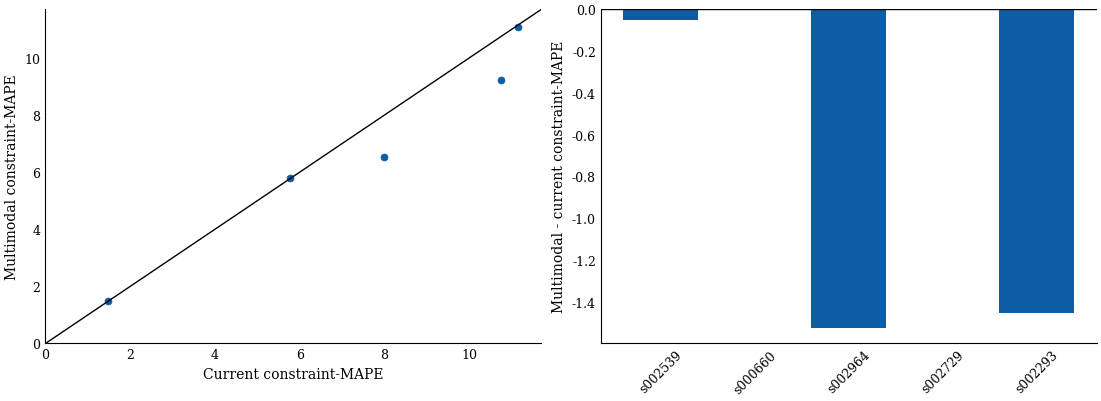

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].scatter(
    comparison['current_constraint_mape'],
    comparison['multimodal_constraint_mape'],
)
limit = max(
    comparison['current_constraint_mape'].max(),
    comparison['multimodal_constraint_mape'].max(),
) * 1.05
axes[0].plot([0, limit], [0, limit], color='black', linewidth=1)
axes[0].set_xlim(0, limit)
axes[0].set_ylim(0, limit)
axes[0].set_xlabel('Current constraint-MAPE')
axes[0].set_ylabel('Multimodal constraint-MAPE')

axes[1].bar(comparison['experiment_id'], comparison['constraint_mape_delta'])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_ylabel('Multimodal - current constraint-MAPE')
axes[1].tick_params(axis='x', rotation=45)

fig.savefig(PLOT_PATH, dpi=160, bbox_inches='tight')
print(f'Saved plot to: {PLOT_PATH}')
display(fig)
plt.close(fig)


In [46]:
focus_experiment = comparison.iloc[0]['experiment_id']
print(f'Inspecting selected k and cluster modes for {focus_experiment}')
display(k_tables[focus_experiment])
display(mode_tables[focus_experiment].sort_values('constraint_mape'))


Inspecting selected k and cluster modes for s002539


,k,silhouette,usable,reason
0,1,0.000000,True,None
1,2,0.570923,True,None
2,3,0.493301,True,None
3,4,0.504601,True,None
4,5,0.462746,True,None


,cluster,sample_index,log_likelihood,constraint_mape,selected
0,0,534,-2764.442062,11.093270,True
1,1,193,-2603.799411,11.143463,False


Saved diagnostic plot to: /home/levytskyi/Documents/inverse-eval/notebooks/05_multimodal_posterior_mape_diagnostic.png


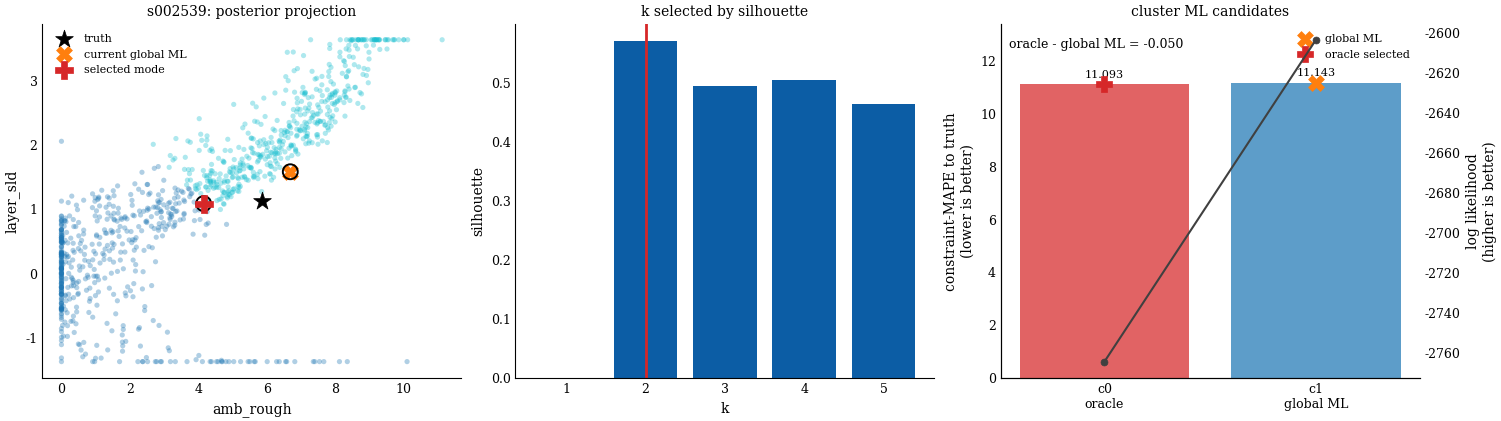

In [47]:
def plot_focus_diagnostic(experiment_id):
    diagnostic = diagnostics[experiment_id]
    samples = diagnostic['samples']
    log_likelihoods = diagnostic['log_likelihoods']
    true_params = diagnostic['true_params']
    true_param_names = diagnostic['true_param_names']
    current = diagnostic['current']
    multimodal = diagnostic['multimodal']
    labels = multimodal['labels']

    widths = np.array([get_constraint_width(name) for name in true_param_names])
    scaled_samples = samples / widths
    spread_order = np.argsort(np.std(scaled_samples, axis=0))
    x_idx, y_idx = spread_order[-2], spread_order[-1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

    scatter = axes[0].scatter(
        samples[:, x_idx],
        samples[:, y_idx],
        c=labels,
        cmap='tab10',
        s=14,
        alpha=0.35,
        linewidths=0,
    )
    axes[0].scatter(
        true_params[x_idx],
        true_params[y_idx],
        marker='*',
        s=180,
        color='black',
        label='truth',
        zorder=5,
    )
    axes[0].scatter(
        current['selected_params'][x_idx],
        current['selected_params'][y_idx],
        marker='X',
        s=130,
        color='tab:orange',
        label='current global ML',
        zorder=6,
    )
    axes[0].scatter(
        multimodal['selected_params'][x_idx],
        multimodal['selected_params'][y_idx],
        marker='P',
        s=150,
        color='tab:red',
        label='selected mode',
        zorder=7,
    )
    for mode in multimodal['mode_rows']:
        params = mode['params']
        axes[0].scatter(
            params[x_idx],
            params[y_idx],
            facecolors='none',
            edgecolors='black',
            s=115,
            linewidths=1.4,
            zorder=6,
        )
    axes[0].set_xlabel(true_param_names[x_idx])
    axes[0].set_ylabel(true_param_names[y_idx])
    axes[0].set_title(f'{experiment_id}: posterior projection')
    axes[0].legend(loc='best', fontsize=8)

    k_table = k_tables[experiment_id]
    axes[1].bar(k_table['k'], k_table['silhouette'].fillna(0.0))
    axes[1].axvline(multimodal['selected_k'], color='tab:red', linewidth=2)
    axes[1].set_xlabel('k')
    axes[1].set_ylabel('silhouette')
    axes[1].set_title('k selected by silhouette')

    mode_table = mode_tables[experiment_id].sort_values('cluster').reset_index(drop=True)
    x_pos = np.arange(len(mode_table))
    global_mask = mode_table['sample_index'] == current['selected_index']
    selected_mask = mode_table['selected']
    bar_colors = ['tab:red' if selected else 'tab:blue' for selected in selected_mask]
    labels = []
    for _, row in mode_table.iterrows():
        tags = []
        if row['sample_index'] == current['selected_index']:
            tags.append('global ML')
        if row['selected']:
            tags.append('oracle')
        label = f"c{int(row['cluster'])}"
        if tags:
            label += '\n' + '\n'.join(tags)
        labels.append(label)

    axes[2].bar(x_pos, mode_table['constraint_mape'], color=bar_colors, alpha=0.72)
    axes[2].scatter(
        x_pos[global_mask],
        mode_table.loc[global_mask, 'constraint_mape'],
        marker='X',
        color='tab:orange',
        s=130,
        label='global ML',
        zorder=4,
    )
    axes[2].scatter(
        x_pos[selected_mask],
        mode_table.loc[selected_mask, 'constraint_mape'],
        marker='P',
        color='tab:red',
        s=130,
        label='oracle selected',
        zorder=5,
    )
    for x, value in zip(x_pos, mode_table['constraint_mape']):
        axes[2].annotate(f'{value:.3f}', (x, value), textcoords='offset points', xytext=(0, 5), ha='center', fontsize=8)
    delta = multimodal['selected_constraint_mape'] - current['constraint_mape']
    axes[2].text(
        0.02,
        0.96,
        f'oracle - global ML = {delta:+.3f}',
        transform=axes[2].transAxes,
        va='top',
        fontsize=9,
    )
    axes[2].set_ylim(0, max(mode_table['constraint_mape']) * 1.2)
    axes[2].set_xticks(x_pos, labels)
    axes[2].set_ylabel('constraint-MAPE to truth\n(lower is better)')
    axes[2].set_title('cluster ML candidates')
    axes[2].legend(loc='upper right', fontsize=8)

    ax_like = axes[2].twinx()
    ax_like.plot(x_pos, mode_table['log_likelihood'], color='0.25', marker='o', lw=1.5, label='log likelihood')
    ax_like.set_ylabel('log likelihood\n(higher is better)')

    fig.savefig(DIAGNOSTIC_PLOT_PATH, dpi=160, bbox_inches='tight')
    print(f'Saved diagnostic plot to: {DIAGNOSTIC_PLOT_PATH}')
    display(fig)
    plt.close(fig)


plot_focus_diagnostic(focus_experiment)
